# Demo: One-Day Dataset Generation (Tracking + Representation + Labeling)

This notebook demonstrates end-to-end dataset generation for **one trading day** from:
`data/raw/XNAS_ITCH_AAPL_mbo_20251201_20260101.dbn.zst`

Pipeline shown in this notebook:
1. Stream DBN MBO messages for a target day/session
2. Track virtual orders
3. Attach entry LOB representation
4. Apply competing-risks labels inline
5. Write a single output parquet dataset

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.order_tracking import OrderTracker
from src.config import CONFIG

dbn_path = PROJECT_ROOT / 'data' / 'raw' / 'XNAS_ITCH_AAPL_mbo_20251201_20260101.dbn.zst'
output_path = PROJECT_ROOT / 'data' / 'datasets' / 'demo_one_day_2025-12-01.parquet'

In [9]:
output_path.parent.mkdir(parents=True, exist_ok=True)

tracker = OrderTracker(
    samples_per_day=100,
    time_censor_s=300.0,
    lookback_period=20,
)

tracker.process_stream(
    file_path=str(dbn_path),
    output_parquet=str(output_path),
    limit=None,
    samples_per_day=100,
    target_day='2025-12-01',
)

print({
    'scheduled_virtual': tracker.inst.scheduled_virtual,
    'spawned_virtual': tracker.inst.spawned_virtual,
})


Processed 100000 messages — last_ts=1764599474038618111, active_virtual=0
Processed 200000 messages — last_ts=1764599810979255041, active_virtual=0
Processed 300000 messages — last_ts=1764600149045829423, active_virtual=0
Processed 400000 messages — last_ts=1764600487210622894, active_virtual=0
Processed 500000 messages — last_ts=1764600815002364656, active_virtual=0
Processed 600000 messages — last_ts=1764601275023374114, active_virtual=0
Processed 700000 messages — last_ts=1764601662811990858, active_virtual=0
Processed 800000 messages — last_ts=1764602150614252948, active_virtual=0
Processed 900000 messages — last_ts=1764602597921527915, active_virtual=1
Processed 1000000 messages — last_ts=1764603062119392717, active_virtual=0
Processed 1100000 messages — last_ts=1764603678064341816, active_virtual=0
Processed 1200000 messages — last_ts=1764604435479626303, active_virtual=0
Processed 1300000 messages — last_ts=1764605178066146106, active_virtual=1
Processed 1400000 messages — last_

In [10]:
df = pd.read_parquet(output_path)
print('shape:', df.shape)
print('columns:', list(df.columns))

print('\nEvent type distribution:')
print(df['event_type'].value_counts(dropna=False).sort_index())

display(df.head(10))

shape: (100, 19)
columns: ['order_id', 'entry_time', 'duration_s', 'event', 'status_reason', 'price', 'side', 'volume', 'order_type', 'best_bid_at_entry', 'best_ask_at_entry', 'best_bid_at_post_trade', 'best_ask_at_post_trade', 'entry_representation', 'event_type', 'event_time_bin', 'post_trade_adverse_move_bps', 'post_trade_spread_bps', 'post_trade_recorded']

Event type distribution:
event_type
0     1
1    90
2     9
Name: count, dtype: int64


,order_id,entry_time,duration_s,event,status_reason,price,side,volume,order_type,best_bid_at_entry,best_ask_at_entry,best_bid_at_post_trade,best_ask_at_post_trade,entry_representation,event_type,event_time_bin,post_trade_adverse_move_bps,post_trade_spread_bps,post_trade_recorded
0,1,1764600029932734208,0.037236,1,FILLED,277650000000,A,1,VIRTUAL,277630000000,277650000000,2.776200e+11,2.776500e+11,"[[-2476.0, -2475.0, -2470.0, -2365.0, -2160.0,...",1,2,-1.080497,1.080555,True
1,0,1764600029932734208,0.202513,1,FILLED,277630000000,B,1,VIRTUAL,277630000000,277650000000,2.776200e+11,2.776400e+11,"[[-2476.0, -2475.0, -2470.0, -2365.0, -2160.0,...",1,5,-0.360192,0.720383,True
2,3,1764600089321744384,0.158892,1,FILLED,277430000000,A,1,VIRTUAL,277390000000,277430000000,2.774100e+11,2.774400e+11,"[[-4547.0, -2241.0, -2134.0, -2119.0, -2116.0,...",1,5,-0.720903,1.081373,True
3,2,1764600089321744384,0.778946,1,FILLED,277390000000,B,1,VIRTUAL,277390000000,277430000000,2.774200e+11,2.774400e+11,"[[-4547.0, -2241.0, -2134.0, -2119.0, -2116.0,...",1,8,-1.802516,0.720903,True
4,5,1764600340647649024,0.309396,1,FILLED,276360000000,A,1,VIRTUAL,276320000000,276360000000,2.763300e+11,2.763600e+11,"[[-3602.0, -3477.0, -3327.0, -3082.0, -2877.0,...",1,6,-1.085541,1.085600,True
5,4,1764600340647649024,2.195586,1,FILLED,276320000000,B,1,VIRTUAL,276320000000,276360000000,2.762800e+11,2.763100e+11,"[[-3602.0, -3477.0, -3327.0, -3082.0, -2877.0,...",2,10,0.361899,1.085796,True
6,6,1764600889898737664,0.023155,1,FILLED,277140000000,B,1,VIRTUAL,277140000000,277170000000,2.771200e+11,2.771400e+11,"[[-3756.0, -3636.0, -3535.0, -3435.0, -3314.0,...",1,1,0.000000,0.721683,True
7,7,1764600889898737664,0.620635,1,FILLED,277170000000,A,1,VIRTUAL,277140000000,277170000000,2.771600e+11,2.772000e+11,"[[-3756.0, -3636.0, -3535.0, -3435.0, -3314.0,...",1,8,-0.360789,1.443106,True
8,9,1764600918993723392,0.066048,1,FILLED,277370000000,A,1,VIRTUAL,277320000000,277370000000,2.773600e+11,2.773800e+11,"[[-4134.0, -3986.0, -3782.0, -3682.0, -3371.0,...",1,3,-0.360529,0.721059,True
9,8,1764600918993723392,2.249339,1,FILLED,277320000000,B,1,VIRTUAL,277320000000,277370000000,2.773200e+11,2.773500e+11,"[[-4134.0, -3986.0, -3782.0, -3682.0, -3371.0,...",1,10,-1.081783,1.081724,True


In [11]:
sample_mat = df['entry_representation'].iloc[0]
arr = np.stack([np.asarray(row, dtype=np.float32) for row in sample_mat])
print('entry_representation shape (lookback, 2W+1):', arr.shape)
print('first time-step (row 0):', arr[0, :])
print('last time-step  (row -1):', arr[-1, :])


entry_representation shape (lookback, 2W+1): (20, 41)
first time-step (row 0): [-2476. -2475. -2470. -2365. -2160. -2120. -2096. -1516. -1391. -1381.
 -1377. -1377. -1282. -1157. -1027.  -871.  -746.  -611.  -486.  -226.
     0.     0.     0.     0.    30.   135.   180.   265.   329.   364.
   489.   514.   539.   575.   700.   705.   744.   749.   888.   933.
  1033.]
last time-step  (row -1): [-2455. -2454. -2449. -2344. -2139. -1979. -1875. -1295. -1290. -1280.
 -1260. -1260. -1140. -1005.  -880.  -714.  -489.  -344.  -219.   -84.
     0.    40.    70.   185.   270.   366.   401.   487.   551.   576.
   701.   726.   751.   762.   862.   867.   906.   911.  1050.  1055.
  1155.]


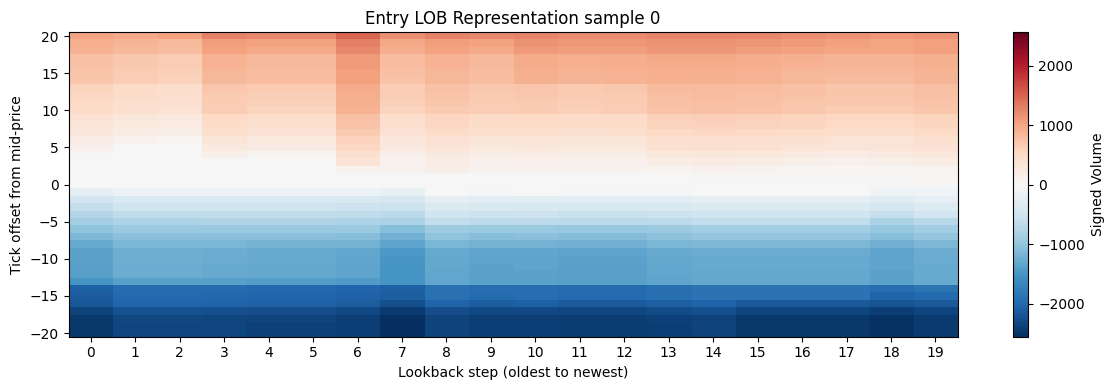

In [ ]:
window = CONFIG.features.window
offsets = list(range(-window, window + 1))

sample_mat = df['entry_representation'].iloc[0]
arr = np.stack([np.asarray(row, dtype=np.float32) for row in sample_mat])  # (lookback, 2W+1)

vmax = np.abs(arr).max() or 1.0

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    arr.T,
    aspect='auto',
    origin='lower',
    extent=[-0.5, arr.shape[0] - 0.5, offsets[0] - 0.5, offsets[-1] + 0.5],
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax,
)
ax.set_title('Entry LOB Representation sample 0')
ax.set_xlabel('Lookback step (oldest to newest)')
ax.set_ylabel('Tick offset from mid-price')
ax.set_xticks(range(arr.shape[0]))
fig.colorbar(im, ax=ax, label='Signed Volume')
plt.tight_layout()
plt.show()
